In [1]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
import os

dataset_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset"

print(os.listdir(dataset_path))

['color', 'grayscale', 'segmented']


In [3]:
import os

color_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset\color"

print("Number of classes:", len(os.listdir(color_path)))
print(os.listdir(color_path)[:10])

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


In [4]:
import os
import pandas as pd

dataset_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset"

data = []

for disease in os.listdir(dataset_path):

    disease_path = os.path.join(dataset_path, disease)

    if os.path.isdir(disease_path):

        for image in os.listdir(disease_path):

            if image.lower().endswith((".jpg", ".jpeg", ".png")):

                data.append([
                    os.path.join(disease_path, image),
                    disease
                ])

df = pd.DataFrame(
    data,
    columns=[
        "image_path",
        "label"
    ]
)

save_path = r"C:\Users\22053\OneDrive\Desktop\plant_ann\dataset\plant_disease_dataset.csv"

df.to_csv(save_path, index=False)

print(df.head())

print(df.shape)

Empty DataFrame
Columns: [image_path, label]
Index: []
(0, 2)


In [5]:
import os

dataset_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset"

print(os.listdir(dataset_path))

['color', 'grayscale', 'segmented']


In [6]:
import os

dataset_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset"

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    print(item, "->", os.path.isdir(full_path))

color -> True
grayscale -> True
segmented -> True


In [7]:
import os

dataset_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset\color"

print("Classes:", len(os.listdir(dataset_path)))

first_class = os.listdir(dataset_path)[0]

print("First class:", first_class)

first_class_path = os.path.join(dataset_path, first_class)

print("Number of images:", len(os.listdir(first_class_path)))

print(os.listdir(first_class_path)[:5])

Classes: 38
First class: Apple___Apple_scab
Number of images: 630
['00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG', '01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG', '01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG', '0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG', '023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG']


In [8]:
import os
import pandas as pd

dataset_path = r"C:\Users\22053\Downloads\archive (2)\plantvillage dataset\color"

data = []

for disease in os.listdir(dataset_path):

    disease_path = os.path.join(dataset_path, disease)

    if os.path.isdir(disease_path):

        for image in os.listdir(disease_path):

            image_path = os.path.join(disease_path, image)

            if os.path.isfile(image_path):

                data.append({
                    "image_path": image_path,
                    "label": disease
                })

df = pd.DataFrame(data)

print(df.head())
print(df.shape)

df.to_csv(
    r"C:\Users\22053\OneDrive\Desktop\plant_ann\dataset\plant_disease_dataset.csv",
    index=False
)

print("CSV Created Successfully!")

                                          image_path               label
0  C:\Users\22053\Downloads\archive (2)\plantvill...  Apple___Apple_scab
1  C:\Users\22053\Downloads\archive (2)\plantvill...  Apple___Apple_scab
2  C:\Users\22053\Downloads\archive (2)\plantvill...  Apple___Apple_scab
3  C:\Users\22053\Downloads\archive (2)\plantvill...  Apple___Apple_scab
4  C:\Users\22053\Downloads\archive (2)\plantvill...  Apple___Apple_scab
(54305, 2)
CSV Created Successfully!


In [9]:
import cv2
import numpy as np

IMG_SIZE = 64

X = []
y = []

for index, row in df.iterrows():

    img = cv2.imread(row["image_path"])

    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype(np.float32) / 255.0

    # Flatten image for ANN
    img = img.flatten()

    X.append(img)
    y.append(row["label"])

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Images Shape :", X.shape)
print("Labels Shape :", y.shape)

Images Shape : (54305, 12288)
Labels Shape : (54305,)


In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import json

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Save class names
class_names = encoder.classes_.tolist()

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

y = to_categorical(y_encoded)

print("Classes:", class_names)
print("Encoded Labels Shape:", y.shape)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (43444, 12288)
Test : (10861, 12288)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(12288,)),
    
    Dense(1024, activation="relu"),
    Dropout(0.4),

    Dense(512, activation="relu"),
    Dropout(0.3),

    Dense(256, activation="relu"),
    Dropout(0.2),

    Dense(38, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │      12,583,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,249,830 (50.54 MB)

 Trainable params: 13,249,830 (50.54 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "plant_disease_ann.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1647 - loss: 3.1613
Epoch 1: val_accuracy improved from None to 0.23179, saving model to plant_disease_ann.keras

Epoch 1: finished saving model to plant_disease_ann.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 276s 249ms/step - accuracy: 0.1647 - loss: 3.1613 - val_accuracy: 0.2318 - val_loss: 2.7654
Epoch 2/20
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.2154 - loss: 2.8857
Epoch 2: val_accuracy improved from 0.23179 to 0.27207, saving model to plant_disease_ann.keras

Epoch 2: finished saving model to plant_disease_ann.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 281s 258ms/step - accuracy: 0.2154 - loss: 2.8857 - val_accuracy: 0.2721 - val_loss: 2.6999
Epoch 3/20
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.2288 - loss: 2.8076
Epoch 3: val_accuracy did not improve from 0.27207
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 393s 361ms/step - accuracy: 0.2288 - loss: 2.8076 - val_accuracy: 0.2566 - val_loss: 2.6843
Epo

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3239 - loss: 2.4170
Test Accuracy: 32.39%
Test Loss: 2.4170


In [ ]:
model.save("plant_disease_ann.keras")
print("Model saved successfully!")

Model saved successfully!


In [18]:
print(y.shape)
print(type(y))

(54305, 38)
<class 'numpy.ndarray'>


In [19]:
# y is already one-hot encoded

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(43444, 12288)
(10861, 12288)


In [20]:
print(y.shape)
print(y[:5])

(54305, 38)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (43444, 12288)
X_test : (10861, 12288)
y_train: (43444, 38)
y_test : (10861, 38)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(12288,)),

    Dense(512, activation="relu"),
    Dropout(0.3),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),

    Dense(38, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 512)                 │       6,291,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,461,094 (24.65 MB)

 Trainable params: 6,461,094 (24.65 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "plant_disease_ann.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3898 - loss: 2.1084
Epoch 1: val_accuracy improved from None to 0.33306, saving model to plant_disease_ann.keras

Epoch 1: finished saving model to plant_disease_ann.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 143s 131ms/step - accuracy: 0.3898 - loss: 2.1084 - val_accuracy: 0.3331 - val_loss: 2.3221
Epoch 2/20
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.3965 - loss: 2.0883
Epoch 2: val_accuracy improved from 0.33306 to 0.38163, saving model to plant_disease_ann.keras

Epoch 2: finished saving model to plant_disease_ann.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 154s 142ms/step - accuracy: 0.3965 - loss: 2.0883 - val_accuracy: 0.3816 - val_loss: 2.1097
Epoch 3/20
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4047 - loss: 2.0551
Epoch 3: val_accuracy improved from 0.38163 to 0.44551, saving model to plant_disease_ann.keras

Epoch 3: finished saving model to plant_disease_ann.keras
1087/1087 ━━━━━━━━━━━━

In [32]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4997 - loss: 1.7150
Test Loss: 1.7150
Test Accuracy: 49.97%


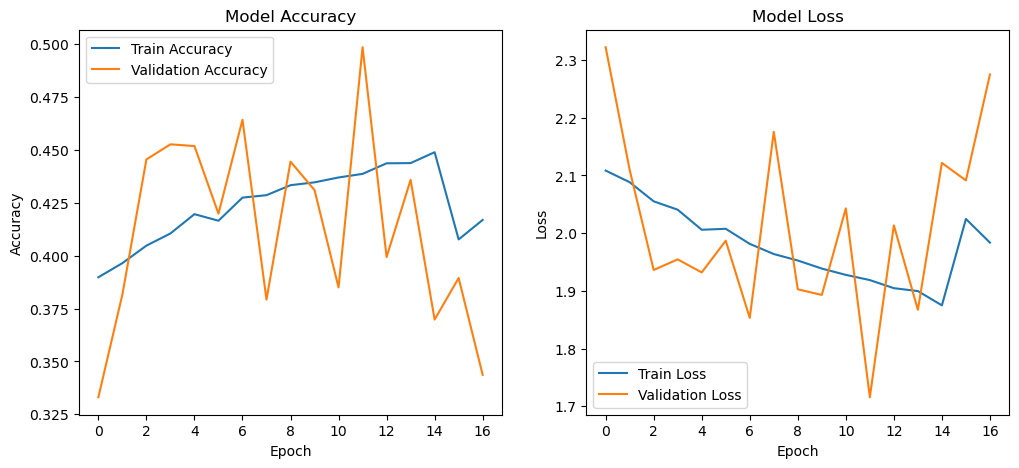

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [33]:
model.save("plant_disease_ann.keras")
print("Model Saved Successfully!")

Model Saved Successfully!


In [34]:
import json

class_names = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Blueberry___healthy",
    "Cherry_(including_sour)___healthy",
    "Cherry_(including_sour)___Powdery_mildew",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___healthy",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Orange___Haunglongbing_(Citrus_greening)",
    "Peach___Bacterial_spot",
    "Peach___healthy",
    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",
    "Potato___Early_blight",
    "Potato___healthy",
    "Potato___Late_blight",
    "Raspberry___healthy",
    "Soybean___healthy",
    "Squash___Powdery_mildew",
    "Strawberry___healthy",
    "Strawberry___Leaf_scorch",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___healthy",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus"
]

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved!")

Class names saved!
